## Assignment 1
**Name:** Jibril Hussaini
**Code:** <student ID>

Linear regression on the California Housing dataset.

### 1. Import required libraries

In [1]:
# Core libraries plus the scikit-learn tools used for the model and evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

### 2. Load the California Housing Dataset

In [2]:
# Load the dataset as a pandas DataFrame (features + target column MedHouseVal)
california = fetch_california_housing(as_frame=True)
df = california.frame

### 3. Display the first 5 rows of the dataset

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 4. Check for missing data (if any)

In [4]:
# Count missing values in each column
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### 5. Handle missing data (impute with mean values)

In [5]:
# Replace any missing value with that column's mean (none here, but kept for completeness)
df = df.fillna(df.mean())
print("Total missing values after imputation:", int(df.isnull().sum().sum()))

Total missing values after imputation: 0


### 6. Feature scaling using StandardScaler

In [6]:
# Separate features from the target, then standardise the features to mean 0 / variance 1
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 7. Split the dataset into train and test sets

In [7]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (16512, 8) | Test: (4128, 8)


### 8. Train a linear regression model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.12,-0.31,...,-0.04,-0.9 ,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.068
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[181.17,168.83,146.88,...,104.54, 35.69, 27.37]"


### 9. Predict on the test set

In [9]:
y_pred = model.predict(X_test)

### 10. Evaluate the model (R² and MSE)

In [10]:
# R2 closer to 1 is better; lower MSE is better
print("R2 score:", round(r2_score(y_test, y_pred), 4))
print("MSE     :", round(mean_squared_error(y_test, y_pred), 4))

R2 score: 0.5758
MSE     : 0.5559


### 11. Display learned weights for each feature and the bias

In [11]:
# One coefficient per feature, plus the intercept (bias)
weights = pd.Series(model.coef_, index=X.columns)
print(weights)
print("\nBias (intercept):", round(model.intercept_, 4))

MedInc        0.852382
HouseAge      0.122382
AveRooms     -0.305116
AveBedrms     0.371132
Population   -0.002298
AveOccup     -0.036624
Latitude     -0.896635
Longitude    -0.868927
dtype: float64

Bias (intercept): 2.0679


### 12. Visualize predicted vs actual house prices

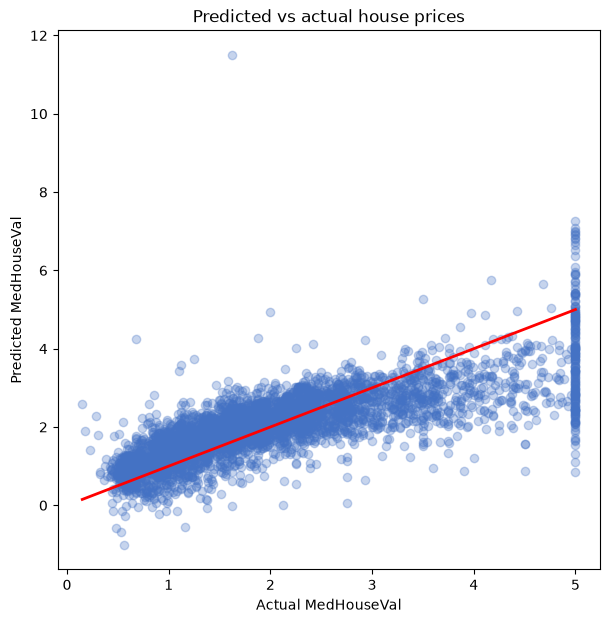

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color="#4472C4")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linewidth=2)   # perfect-prediction line
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Predicted vs actual house prices")
plt.show()